# Zadanie domowe -- interpolacja dwusześcienna

Interpolacja dwusześcienna, to podobnie jak w przypadku interpolacji dwuliniowej, rozszerzenie idei interpolacji jednowymiarowej na dwuwymiarową siatkę.
W trakcie jej obliczania wykorzystywane jest 16 pikseli z otoczenia (dla dwuliniowej 4).
Skutkuje to zwykle lepszymi wynikami - obraz wyjściowy jest bardziej gładki i z mniejszą liczbą artefaktów.
Ceną jest znaczny wzrost złożoności obliczeniowej (zostało to zaobserwowane podczas ćwiczenia).

Interpolacja dana jest wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\end{equation}

Zadanie sprowadza się zatem do wyznaczenia 16 współczynników $a_{ij}$.
W tym celu wykorzystuje się, oprócz wartość w~puntach $A$ (0,0), $B$ (1 0), $C$ (1,1), $D$ (0,1) (por. rysunek dotyczący interpolacji dwuliniowej), także pochodne cząstkowe $A_x$, $A_y$, $A_{xy}$.
Pozwala to rozwiązać układ 16-tu równań.

Jeśli zgrupujemy parametry $a_{ij}$:
\begin{equation}
a = [ a_{00}~a_{10}~a_{20}~a_{30}~a_{01}~a_{11}~a_{21}~a_{31}~a_{02}~a_{12}~a_{22}~a_{32}~a_{03}~a_{13}~a_{23}~a_{33}]
\end{equation}

i przyjmiemy:
\begin{equation}
x = [A~B~D~C~A_x~B_x~D_x~C_x~A_y~B_y~D_y~C_y~A_{xy}~B_{xy}~D_{xy}~C_{xy}]^T
\end{equation}

To zagadnienie można opisać w postaci równania liniowego:
\begin{equation}
Aa = x
\end{equation}
gdzie macierz $A^{-1}$ dana jest wzorem:

\begin{equation}
A^{-1} =
\begin{bmatrix}
1& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0 \\
0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
-3&  3&  0&  0& -2& -1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
2& -2&  0&  0&  1&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0& -3&  3&  0&  0& -2& -1&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  2& -2&  0&  0&  1&  1&  0&  0 \\
-3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0& -3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0 \\
9& -9& -9&  9&  6&  3& -6& -3&  6& -6&  3& -3&  4&  2&  2&  1 \\
-6&  6&  6& -6& -3& -3&  3&  3& -4&  4& -2&  2& -2& -2& -1& -1 \\
2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0 \\
-6&  6&  6& -6& -4& -2&  4&  2& -3&  3& -3&  3& -2& -1& -2& -1 \\
4& -4& -4&  4&  2&  2& -2& -2&  2& -2&  2& -2&  1&  1&  1&  1 \\
\end{bmatrix}
\end{equation}

Potrzebne w rozważaniach pochodne cząstkowe obliczane są wg. następującego przybliżenia (przykład dla punktu A):
\begin{equation}
A_x = \frac{I(i+1,j) - I(i-1,j)}{2}
\end{equation}

\begin{equation}
A_y = \frac{I(i,j+1) - I(i,j-1)}{2}
\end{equation}

\begin{equation}
A_{xy} = \frac{I(i+1,j+1) - I(i-1,j) - I(i,j-1) + I(i,j)}{4}
\end{equation}

## Zadanie

Wykorzystując podane informacje zaimplementuj interpolację dwusześcienną.
Uwagi:
- macierz $A^{-1}$ dostępna jest w pliku *ainvert.py*
- trzeba się zastanowić nad potencjalnym wykraczaniem poza zakres obrazka (jak zwykle).

Ponadto dokonaj porównania liczby operacji arytmetycznych i dostępów do pamięci koniecznych przy realizacji obu metod interpolacji: dwuliniowej i dwusześciennej.

parrot.bmp już istnieje
clock.bmp już istnieje
chessboard.bmp już istnieje
ainvert.py już istnieje


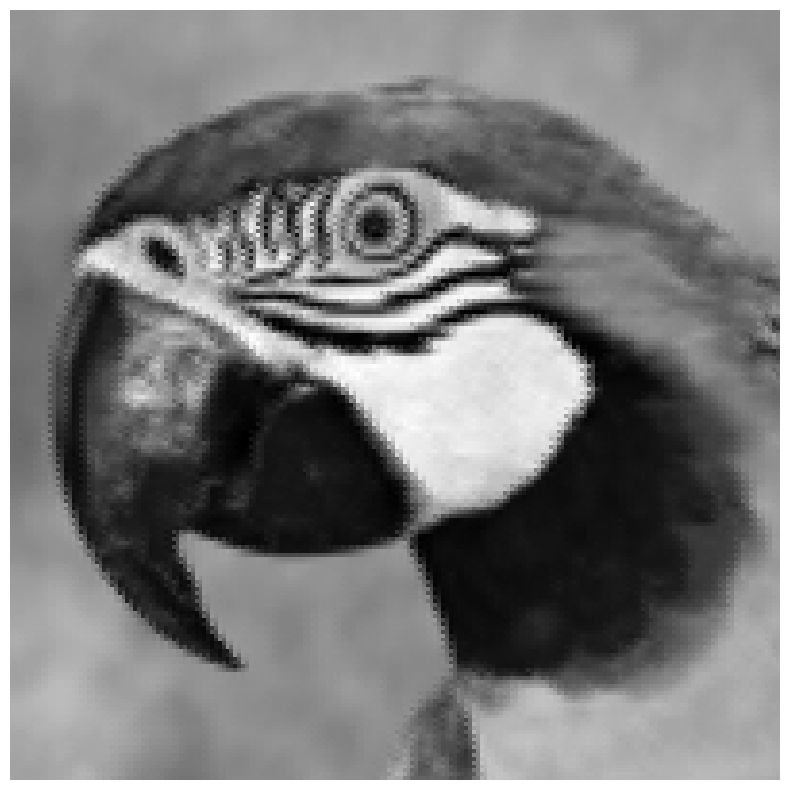

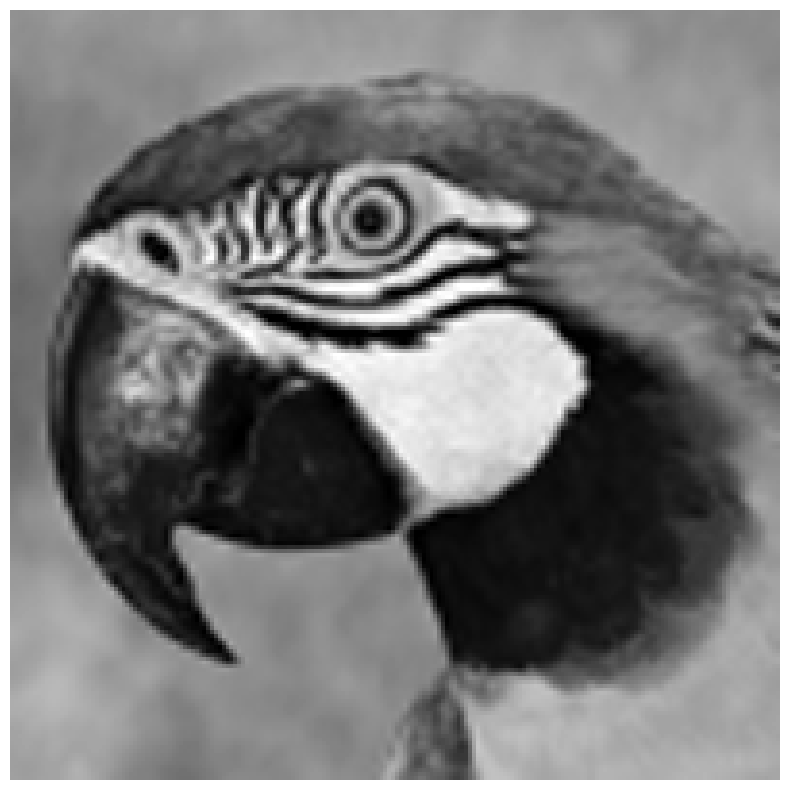

In [ ]:
import os
import urllib.request
import cv2
import numpy as np
from matplotlib import pyplot as plt

def download_file(url, filename):
    if not os.path.exists(filename):
        print(f"Pobieranie: {filename}")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} już istnieje")

download_file(
    "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/parrot.bmp",
    "parrot.bmp"
)

download_file(
    "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/clock.bmp",
    "clock.bmp"
)

download_file(
    "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/chessboard.bmp",
    "chessboard.bmp"
)

download_file(
    "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/ainvert.py",
    "ainvert.py"
)

import ainvert


def bicubic_image(img, kx, ky):
    img = img.astype('float32')
    x_org, y_org = img.shape

    x_new = int(round(x_org * kx))
    y_new = int(round(y_org * ky))

    img_new = np.zeros((x_new, y_new), dtype=np.float32)

    # Padding (2 piksele z każdej strony)
    img_p = np.pad(img, 2, mode='edge')

    def get_grads(r, c):
        f = img_p[r, c]
        fx = (img_p[r + 1, c] - img_p[r - 1, c]) / 2
        fy = (img_p[r, c + 1] - img_p[r, c - 1]) / 2
        fxy = (img_p[r + 1, c + 1] - img_p[r - 1, c + 1]
               - img_p[r + 1, c - 1] + img_p[r - 1, c - 1]) / 4
        return f, fx, fy, fxy

    for i in range(x_new):
        for j in range(y_new):

            # współrzędne w obrazie źródłowym
            xf = i / kx
            yf = j / ky

            i1 = int(np.floor(xf))
            j1 = int(np.floor(yf))

            dx = xf - i1
            dy = yf - j1

            ii1, jj1 = i1 + 2, j1 + 2
            ii2, jj2 = ii1 + 1, jj1 + 1

            # pobranie wartości i pochodnych
            vA, Ax, Ay, Axy = get_grads(ii1, jj1)
            vB, Bx, By, Bxy = get_grads(ii1, jj2)
            vC, Cx, Cy, Cxy = get_grads(ii2, jj1)
            vD, Dx, Dy, Dxy = get_grads(ii2, jj2)

            vec = np.array([
                vA, vB, vD, vC,
                Ax, Bx, Dx, Cx,
                Ay, By, Dy, Cy,
                Axy, Bxy, Dxy, Cxy
            ])

            # współczynniki wielomianu
            a_coeffs = np.asarray(ainvert.A_invert @ vec).reshape(4, 4)

            # obliczenie wartości piksela
            pixel_val = 0.0
            for m in range(4):
                for n in range(4):
                    pixel_val += a_coeffs[m, n] * (dx ** m) * (dy ** n)

            img_new[i, j] = np.clip(pixel_val, 0, 255)

    img_new = img_new.astype(np.uint8)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_new, cmap="gray")
    plt.axis('off')
    plt.show()

    return img_new

image = cv2.imread('parrot.bmp', cv2.IMREAD_GRAYSCALE)
bicubic_image(image, 2, 2)

parrot = cv2.imread('parrot.bmp', cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(10,10))
parrot = cv2.resize(parrot, (parrot.shape[1] * 2, parrot.shape[0] * 2), interpolation=cv2.INTER_CUBIC)
plt.imshow(parrot, cmap="gray")
plt.axis('off')
plt.show()